In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv", low_memory=False)
df = df.iloc[1:].reset_index(drop=True)

print(df.shape)  # (nr_linii, nr_coloane)
print(df.head())

(25973, 369)
  Time from Start to Finish (seconds)     Q1   Q2         Q3  \
0                                 910  50-54  Man      India   
1                                 784  50-54  Man  Indonesia   
2                                 924  22-24  Man   Pakistan   
3                                 575  45-49  Man     Mexico   
4                                 781  45-49  Man      India   

                  Q4                       Q5          Q6 Q7_Part_1 Q7_Part_2  \
0  Bachelor’s degree                    Other  5-10 years    Python         R   
1    Master’s degree  Program/Project Manager   20+ years       NaN       NaN   
2    Master’s degree        Software Engineer   1-3 years    Python       NaN   
3    Doctoral degree       Research Scientist   20+ years    Python       NaN   
4    Doctoral degree                    Other   < 1 years    Python       NaN   

  Q7_Part_3  ... Q38_B_Part_3 Q38_B_Part_4   Q38_B_Part_5 Q38_B_Part_6  \
0       NaN  ...          NaN          Na

In [5]:
#1) Numărul de respondenți
n_resp = len(df)
print("Număr respondenți:", n_resp)

Număr respondenți: 25973


In [6]:
#2) Număr și tipul informațiilor (atribute) pentru un respondent
print("Număr atribute (coloane):", df.shape[1])
print(df.columns)
print(df.dtypes)

Număr atribute (coloane): 369
Index(['Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5',
       'Q6', 'Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3',
       ...
       'Q38_B_Part_3', 'Q38_B_Part_4', 'Q38_B_Part_5', 'Q38_B_Part_6',
       'Q38_B_Part_7', 'Q38_B_Part_8', 'Q38_B_Part_9', 'Q38_B_Part_10',
       'Q38_B_Part_11', 'Q38_B_OTHER'],
      dtype='str', length=369)
Time from Start to Finish (seconds)    str
Q1                                     str
Q2                                     str
Q3                                     str
Q4                                     str
                                      ... 
Q38_B_Part_8                           str
Q38_B_Part_9                           str
Q38_B_Part_10                          str
Q38_B_Part_11                          str
Q38_B_OTHER                            str
Length: 369, dtype: object


In [7]:
#3) Numărul de respondenți cu date complete
complete_all = df.dropna().shape[0]
print("Complet pe TOATE cele 369 coloane:", complete_all)

Complet pe TOATE cele 369 coloane: 0


In [10]:
#4) Durata medie a studiilor superioare (ani)
def edu_years(x):
    if pd.isna(x): return np.nan
    if "Bachelor" in x: return 3
    if "Master" in x: return 5
    if "Doctoral" in x: return 8
    if "Professional doctorate" in x: return 8
    if "Some college" in x: return 1.5
    if "No formal education" in x: return 0
    if "I prefer not" in x: return np.nan
    return np.nan

df["edu_years"] = df["Q4"].apply(edu_years)

mean_all = df["edu_years"].mean()
mean_ro = df.loc[df["Q3"]=="Romania", "edu_years"].mean()
mean_ro_w = df.loc[(df["Q3"]=="Romania") & (df["Q2"]=="Woman"), "edu_years"].mean()

print("Media ani studii (toți):", mean_all)
print("Media ani studii (România):", mean_ro)
print("Media ani studii (România, femei):", mean_ro_w)

Media ani studii (toți): 4.269845340487651
Media ani studii (România): 4.758333333333334
Media ani studii (România, femei): 5.34375


In [11]:
#5) Numărul de respondenți femei din România cu date complete
rom_w_complete = df[(df["Q3"]=="Romania") & (df["Q2"]=="Woman")].dropna()
print("Femei România (complete pe Q1–Q6):", len(rom_w_complete))

Femei România (complete pe Q1–Q6): 0


In [12]:
#6) Femei din România care programează în Python / C++ + intervalul de vârstă dominant
lang_cols = [c for c in df.columns if c.startswith("Q7_Part_")]

def uses_language(sub_df, lang):
    return sub_df[lang_cols].eq(lang).any(axis=1)

rom_w = df[(df["Q3"]=="Romania") & (df["Q2"]=="Woman")].copy()
rom_w["uses_python"] = uses_language(rom_w, "Python")
rom_w["uses_cpp"] = uses_language(rom_w, "C++")

n_py = rom_w["uses_python"].sum()
n_cpp = rom_w["uses_cpp"].sum()

print("Femei RO care folosesc Python:", n_py)
print("Femei RO care folosesc C++:", n_cpp)

# Interval vârstă cu cele mai multe
top_age_py = rom_w.loc[rom_w["uses_python"], "Q1"].value_counts()
top_age_cpp = rom_w.loc[rom_w["uses_cpp"], "Q1"].value_counts()

print("\nDistribuție vârstă (Python):\n", top_age_py)
print("\nDistribuție vârstă (C++):\n", top_age_cpp)

if len(top_age_py)>0:
    print("\nVârsta dominantă Python:", top_age_py.idxmax())
if len(top_age_cpp)>0:
    print("Vârsta dominantă C++:", top_age_cpp.idxmax())

Femei RO care folosesc Python: 12
Femei RO care folosesc C++: 4

Distribuție vârstă (Python):
 Q1
35-39    5
22-24    3
25-29    2
18-21    1
40-44    1
Name: count, dtype: int64

Distribuție vârstă (C++):
 Q1
18-21    1
25-29    1
22-24    1
35-39    1
Name: count, dtype: int64

Vârsta dominantă Python: 35-39
Vârsta dominantă C++: 18-21


In [13]:
# 7) Domeniul de valori posibile + extreme pentru fiecare atribut
def analyze_attribute_ranges(df):
    attribute_summary = {}
    for col in df.columns:
        unique_values = df[col].dropna().unique()
        num_unique_values = len(unique_values)
        try:
            numeric_values = pd.to_numeric(df[col].dropna(), errors='coerce')
            min_val, max_val = numeric_values.min(), numeric_values.max()
        except:
            min_val, max_val = None, None
        attribute_summary[col] = {
            "Număr de valori posibile": num_unique_values,
            "Minim": min_val,
            "Maxim": max_val,
            "Exemple de valori": unique_values[:5]
        }
    return pd.DataFrame.from_dict(attribute_summary, orient='index')
attribute_summary_df = analyze_attribute_ranges(df)
print(attribute_summary_df.head(20))

                                     Număr de valori posibile  Minim  \
Time from Start to Finish (seconds)                      4421  120.0   
Q1                                                         11    NaN   
Q2                                                          5    NaN   
Q3                                                         66    NaN   
Q4                                                          7    NaN   
Q5                                                         15    NaN   
Q6                                                          7    NaN   
Q7_Part_1                                                   1    NaN   
Q7_Part_2                                                   1    NaN   
Q7_Part_3                                                   1    NaN   
Q7_Part_4                                                   1    NaN   
Q7_Part_5                                                   1    NaN   
Q7_Part_6                                                   1   

In [17]:
#8). Transformarea vechimii în programare și analiza statistică
map_q6 = {
    "I have never written code": 0,
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25  # alegere simplă (poți schimba)
}

df["code_years"] = df["Q6"].map(map_q6)

stats = {
    "min": df["code_years"].min(),
    "max": df["code_years"].max(),
    "mean": df["code_years"].mean(),
    "std": df["code_years"].std(),
    "median": df["code_years"].median(),
}
print(stats)


def plot_python_age_distribution(df, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df["Q1"], order=df["Q1"].value_counts().index)
    plt.xlabel("Număr de respondenți")
    plt.ylabel("Categorie de vârstă")
    plt.title(title)
    plt.show()

{'min': np.float64(0.0), 'max': np.float64(25.0), 'mean': np.float64(5.281061101913526), 'std': np.float64(6.79090316922895), 'median': np.float64(2.0)}


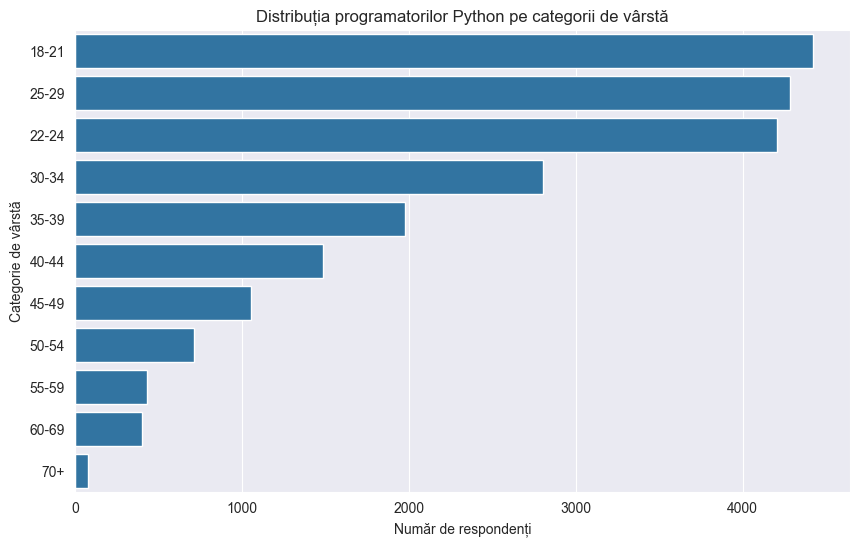

In [18]:
#9).distributia respondentilor care programeaza in Python pe categorii de varsta
python_users = df[df["Q7_Part_1"] == "Python"]
plot_python_age_distribution(python_users, "Distribuția programatorilor Python pe categorii de vârstă")

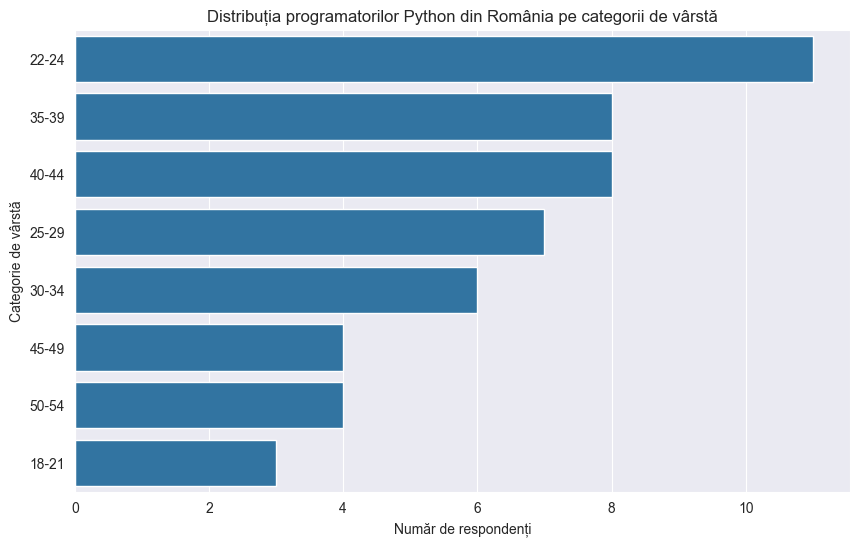

In [19]:
#10).distributia respondentilor din Romania care programeaza in Python pe categorii de varsta
romania_python_users = python_users[python_users["Q3"] == "Romania"]
plot_python_age_distribution(romania_python_users, "Distribuția programatorilor Python din România pe categorii de vârstă")

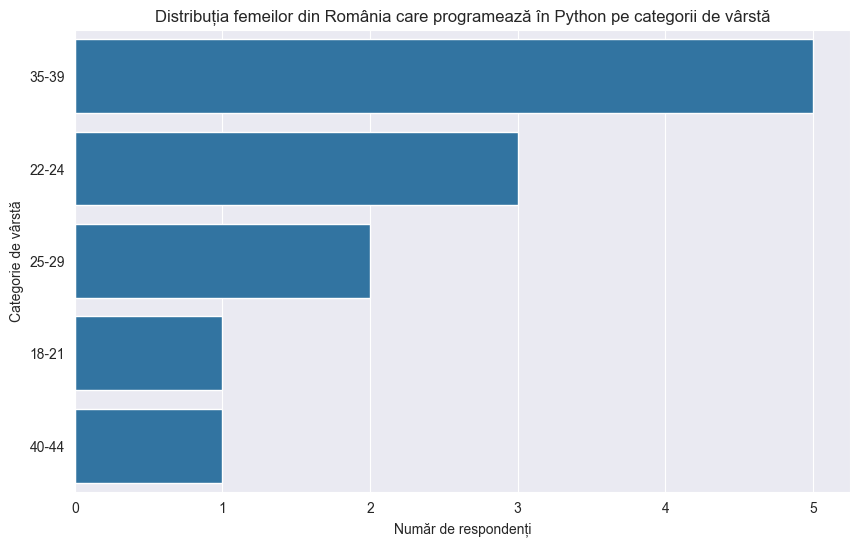

In [20]:
#11).distributia respondentilor femei din Romania care programeaza in Python pe categorii de varsta
romania_women_python_users = romania_python_users[romania_python_users["Q2"] == "Woman"]
plot_python_age_distribution(romania_women_python_users, "Distribuția femeilor din România care programează în Python pe categorii de vârstă")

def plot_outliers_experience(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df["code_years"])
    plt.xlabel("Ani de experiență în programare")
    plt.title("Identificarea outlierilor în experiența de programare")
    plt.show()

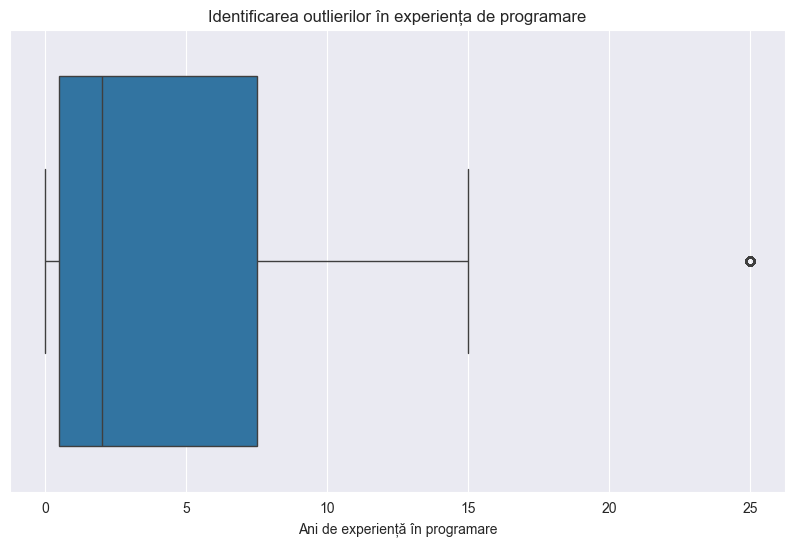

In [22]:
#12).respondentii care pot fi considerati "outlieri" din punct de vedere al vechimii in programare (puteti folositi un boxplot pentru a identifica aceste valori)
exp_map = {
    "I have never written code": 0,
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25
}

df["code_years"] = df["Q6"].map(exp_map)

plot_outliers_experience(df)